### 회귀 분석 순서 
1. 데이터를 확인 
2. 데이터를 정제 
3. 데이터를 분할
4. 데이터를 스케일링
5. 모델 학습
6. 성능 평가 및 예측값 저장

In [1]:
import pandas as pd

In [2]:
# boston.csv 파일 로드 
boston = pd.read_csv("../../csv/boston.csv")

In [3]:
# 상위 5개를 데이터를 확인 
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
# 정보를 확인 
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  Price    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [5]:
# 결측치의 개수를 확인 
boston.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
Price      0
dtype: int64

In [6]:
boston.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
# 데이터의 분포도를 확인 
# price와 나머지 컬럼들의 데이터 분포도
import matplotlib.pyplot as plt 
import seaborn as sns

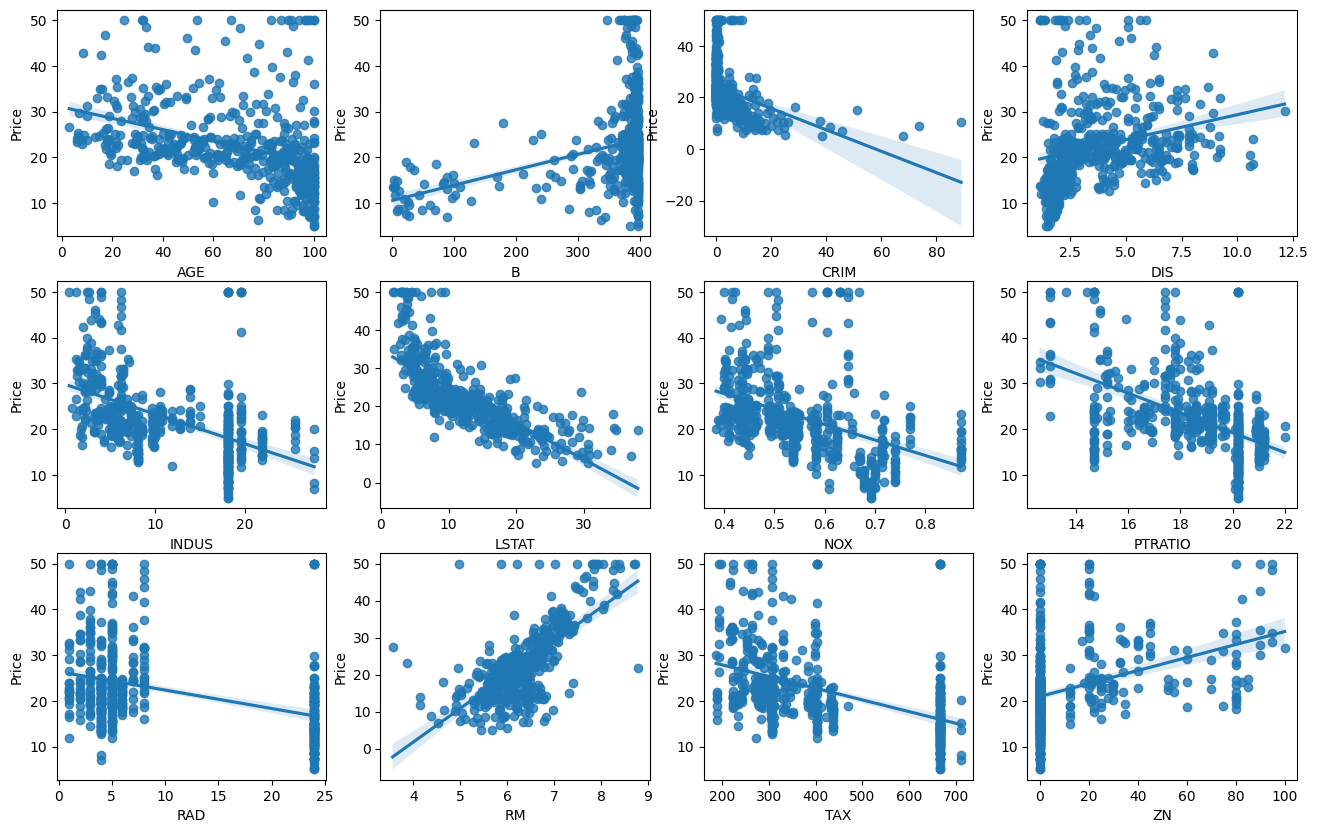

In [9]:
# 그래프를 12개의 공간으로 나눠준다. 
fig, axs = plt.subplots(
    figsize = (16, 10), 
    ncols= 4, 
    nrows= 3
)
# 특정 컬럼의 이름을 제거한 리스트를 생성
features = boston.columns.difference(['Price', 'CHAS'])

for i, feature in zip(range(12),features):
    # i는 0부터 11까지 반복 
    # 좌표 값을 생성 
    row = int(i/4)
    col = i % 4
    sns.regplot(
        x = feature, 
        y = boston['Price'], 
        data = boston, 
        ax = axs[row][col]
    )
plt.show()


In [10]:
# 데이터를 분할
from sklearn.model_selection import train_test_split

In [13]:
x = boston[features].values
y = boston['Price'].values

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size= 0.2, random_state = 42
)

In [15]:
print("train 데이터에서 price의 평균", y_train.mean())
print('test 데이터에서 price의 평균', y_test.mean())

train 데이터에서 price의 평균 22.796534653465343
test 데이터에서 price의 평균 21.488235294117644


In [22]:
# 스케일러 이용하여 각 데이터들의 범위를 고정 
# min-max 스케일러를 이용한 스케일링
from sklearn.preprocessing import MinMaxScaler

# class 생성 
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train_sc = scaler.transform(x_train)
# x_train_sc
x_test_sc = scaler.transform(x_test)
# x_test_sc

In [23]:
# 모델 학습 
# 회귀 분석 (linearRegression)
from sklearn.linear_model import LinearRegression

linear = LinearRegression()

# 모델 학습 데이터를 대입 
linear.fit(x_train_sc, y_train)

LinearRegression()

In [ ]:
# predit() 함수를 이용하여 학습데이터를 예측 값 저장 
pred = linear.predict(x_train_sc)
pred

In [25]:
# test 데이터를 이용한 예측값 저장
pred_t = linear.predict(x_test_sc)

In [26]:
pred_df = pd.DataFrame(pred, columns=['pred price'])
atual = pd.DataFrame(y_train, columns=['actual price'])

In [27]:
df = pd.concat([pred_df, atual], axis=1)
df.head()

,pred price,actual price
0,11.020177,12.0
1,19.488730,19.9
2,23.051827,19.4
3,12.107957,13.4
4,18.421556,18.2


In [28]:
pred_t_df = pd.DataFrame(pred_t, columns=['pred price'])
actual2 = pd.DataFrame(y_test, columns=['actual price'])
df2 = pd.concat([pred_t_df, actual2], axis=1)
df2.head()

,pred price,actual price
0,29.218660,23.6
1,33.551467,32.4
2,14.810658,13.6
3,25.084725,22.8
4,19.173927,16.1
